# **MIS 6382.003 Final Project - Group 2**
# **Scenario #9: Data about Lodging rentals offered by a travel agency website.**
**Fall 2025 | Prof. Rabih Neouchi**


# **Project Introduction**

This project analyzes a dataset of lodging rentals offered by a travel agency website. The dataset contains information about different types of lodgings, including Hotel Rooms, Mountain Cabins, and Beach Houses, along with their prices, customer ratings, booking type (Travel or Vacation), and average revenue.

The main goal of this project is to explore pricing patterns, customer satisfaction, revenue behavior, and category-wise trends using data visualization and basic data analysis techniques. Through this analysis, we aim to understand how different lodging categories perform and what factors may influence pricing, ratings, and demand.

# Step 1: Automatically download the raw .dat dataset from Google Drive

In [1]:

# Step 1: Download the .dat file automatically from Google Drive (with safe fallback)

!pip install gdown -q

import gdown
import os

GDRIVE_FILE_ID = "13OFi0nogSESEIhdLNKRheF9gPDzwSbsA"   # your real file ID
DAT_FILE = "Lodgingpkl638200302.dat"                # your local file name

downloaded = False

try:
    if not os.path.exists(DAT_FILE):
        url = f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}"
        print("Downloading .dat from Google Drive...")
        gdown.download(url, DAT_FILE, quiet=False)

        if os.path.exists(DAT_FILE):
            downloaded = True
            print("Download successful:", DAT_FILE)
    else:
        downloaded = True
        print("DAT file already exists. Skipping download.")
except Exception as e:
    print("Download failed due to error:", e)

# Fallback instruction for manual upload
if not downloaded:
    print("If automatic download failed, please upload the .dat file manually via the Colab file sidebar and re-run this cell.")

print("Using DAT file:", DAT_FILE)


DAT file already exists. Skipping download.
Using DAT file: Lodgingpkl638200302.dat


## Step 2 : OOP Classes
This project uses Object-Oriented Programming to model lodging rental data in a structured and reusable way.

A base class Lodging is created to store common attributes such as date, name, category, type, rating, price, and average revenue.

A unique ID is automatically assigned to each object using Python’s id() function.

The __str__ method is implemented to return each object in the required CSV format, allowing easy file conversion.

Using inheritance, two intermediate subclasses are created:

Travel for travel-based properties

Vacation for vacation-based properties

Final subclasses are created from these:

HotelRoom and MountainCabin inherit from Travel

BeachHouse inherits from Vacation


In [2]:
# Step 1: Base class Lodging using Object-Oriented Programming (OOP)
class Lodging:
    def __init__(self, date, name, category, type, rating, price, average_revenue):
        self.date = date
        self.name = name
        self.category = category
        self.type = type
        self.rating = rating
        self.price = price
        self.average_revenue = average_revenue

        # Step 2: Assign unique ID to each object
        self.unique_id = id(self)

    # Step 3: String representation in required CSV format
    def __str__(self):
        return (
            f"{self.unique_id}, {self.date}, {self.name}, "
            f"{self.category}, {self.type}, "
            f"{self.rating}, {self.price}, {self.average_revenue}"
        )


# Step 4–5: Travel and Vacation subclasses using inheritance
class Travel(Lodging):
    def __init__(self, date, name, category, rating, price, average_revenue):
        super().__init__(date, name, category, "Travel", rating, price, average_revenue)


class Vacation(Lodging):
    def __init__(self, date, name, category, rating, price, average_revenue):
        super().__init__(date, name, category, "Vacation", rating, price, average_revenue)


# Step 6–7: Final category subclasses inheriting from Travel and Vacation
class HotelRoom(Travel):
    def __init__(self, date, name, rating, price, average_revenue):
        category = "HotelRoom"
        super().__init__(date, name, category, rating, price, average_revenue)


class MountainCabin(Travel):
    def __init__(self, date, name, rating, price, average_revenue):
        category = "MountainCabin"
        super().__init__(date, name, category, rating, price, average_revenue)


class BeachHouse(Vacation):
    def __init__(self, date, name, rating, price, average_revenue):
        category = "BeachHouse"
        super().__init__(date, name, category, rating, price, average_revenue)


## Test example from instructions

In [3]:
# Step 8: Test example from instructions
BeachHouseLodging = BeachHouse("2024-10-08", "Cottage BeachHouse", 1.0, 85.32, 69020.0)
print(str(BeachHouseLodging))


132372994292672, 2024-10-08, Cottage BeachHouse, BeachHouse, Vacation, 1.0, 85.32, 69020.0


## Step 3 : Load pickle → generate CSV

In [4]:
# Load objects from .dat file and create CSV (if needed)

import pickle

CSV_FILE = "project_dataset.csv"

# --- Load all objects from the .dat file ---
with open(DAT_FILE, 'rb') as fb:
    try:
        while True:
            objects = pickle.load(fb)   # last load has the full list
    except EOFError:
        pass

print("Total objects loaded:", len(objects))
print("Type of first object:", type(objects[0]))
print("First object as CSV row:", str(objects[0]))

# --- Create CSV only if it doesn't already exist ---
if not os.path.exists(CSV_FILE):
    print("\nCSV not found – creating", CSV_FILE, "...")
    with open(CSV_FILE, 'w') as f:
        f.write("unique_id,date,name,category,type,rating,price,average_revenue\n")
        for obj in objects:
            f.write(str(obj) + "\n")
    print("CSV created at:", CSV_FILE)
else:
    print("\nCSV already exists – using existing file:", CSV_FILE)


Total objects loaded: 12000
Type of first object: <class '__main__.HotelRoom'>
First object as CSV row: 137576474858208, 2024-08-13, Presidential Suite, HotelRoom, Travel, 4, 1087, 61359.71

CSV not found – creating project_dataset.csv ...
CSV created at: project_dataset.csv


## Dataset Overview

The CSV file group2_project_dataset.csv is generated from the lodging .dat
file that was provided for the project.  
It contains 12,000 rows, where each row represents one lodging listing.

**Columns and data types**

- unique_id (int) – unique identifier for each listing  
- date (datetime) – date when the listing was recorded in the dataset  
- name (string) – name of the lodging (e.g., Presidential Suite)  
- category (string) – lodging category: HotelRoom, MountainCabin, or BeachHouse
- type (string) – booking type: Travel or Vacation
- rating (float, 1–5) – customer rating score  
- price (float, USD per night) – nightly price of the listing  
- average_revenue (float, USD) – average revenue generated by the listing  


## Step 4 : Parse, clean, and prepare data

In [5]:
# Parse, clean, and prepare data

import pandas as pd
import numpy as np

# Load the CSV generated earlier
df = pd.read_csv(CSV_FILE)

print("Head:")
print(df.head())

# ---- Parse / convert types ----
df["date"] = pd.to_datetime(df["date"], errors="coerce")

numeric_cols = ["rating", "price", "average_revenue"]

# Convert numeric columns
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ---- Handle numeric missing values: median ----
if df[numeric_cols].isna().any().any():
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

# ---- Handle categorical missing values: mode ----
categorical_cols = ["name", "category", "type"]

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode().iloc[0])

print("\nInfo after parsing / cleaning:")
print(df.info())


Head:
         unique_id         date                 name    category     type  \
0  137576474858208   2024-08-13   Presidential Suite   HotelRoom   Travel   
1  137576474856912   2024-01-26      Executive Suite   HotelRoom   Travel   
2  137576474853936   2024-03-20   Presidential Suite   HotelRoom   Travel   
3  137576474856624   2024-07-02   Presidential Suite   HotelRoom   Travel   
4  137576474858976   2024-08-11      Executive Suite   HotelRoom   Travel   

  rating  price average_revenue  
0      4   1087        61359.71  
1      4    582        72920.83  
2      2   1042        65472.27  
3      4    976        60051.04  
4      3    690        61370.81  

Info after parsing / cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   unique_id        12000 non-null  int64         
 1   date             11518 

## How we read, parse, clean, and prepare the data

We first load the data from `group2_project_dataset.csv` into a pandas DataFrame.  
Then we **parse and clean** the columns as follows:

- Convert the `date` column to `datetime` using `pd.to_datetime(...)`.  
- Convert the numeric fields `rating`, `price`, and `average_revenue` to numeric using `pd.to_numeric(..., errors="coerce")`.  
- Check for missing values using `df.isna().sum()`.

For **numeric columns**, any missing values (if they appear) are filled using the **median** of that column.  
For **categorical columns** (`name`, `category`, `type`), we would fill any missing values using the **mode** (most frequent value).  
In this dataset, the categorical columns did not show missing values, but the code is written to handle them if they occur.

This preparation step ensures that all variables have consistent types and no gaps, so the visualizations and analysis in the next section are based on a clean dataset.


## Plotting setup

In [6]:
# Plotting setup

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)
sns.set(style="whitegrid")


## Step 5 Exploratory Data Analysis & Visualizations

Below are the visualizations created using the cleaned dataset.


### Visualization 1: Average Price by Lodging Category (Bar Chart)

This bar chart compares the average price across the three lodging categories in the dataset:
HotelRoom, MountainCabin, and BeachHouse.

By grouping the data by category and computing the mean price for each group, the visualization shows how lodging prices vary across categories.

This helps identify which category tends to be priced higher and may indicate differences in demand, amenities, or revenue potential.


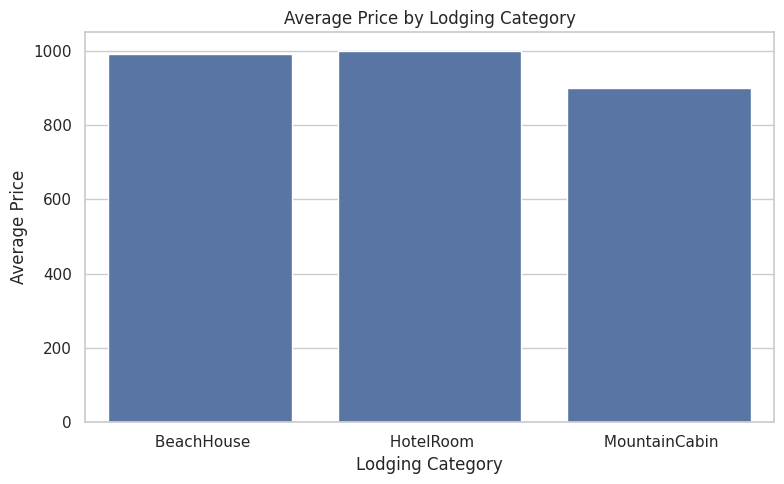

In [7]:
# Visualization 1: Average Price by Lodging Category
# Group and calculate mean price
avg_price_by_category = (
    df.groupby("category", as_index=False)["price"].mean()
      .sort_values("category")
)

# Plot
plt.figure()
sns.barplot(data=avg_price_by_category, x="category", y="price")
plt.title("Average Price by Lodging Category")
plt.xlabel("Lodging Category")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()



### Visualization 2: Price Distribution by Category (Boxplot)

This boxplot shows the **distribution of nightly prices** for each lodging category
(HotelRoom, MountainCabin, BeachHouse).

A boxplot helps visualize the spread, median price, and any outliers within each category.
This allows us to compare how price variability differs across lodging types.
For example, a wider box or presence of extreme data points indicates more variability in pricing.


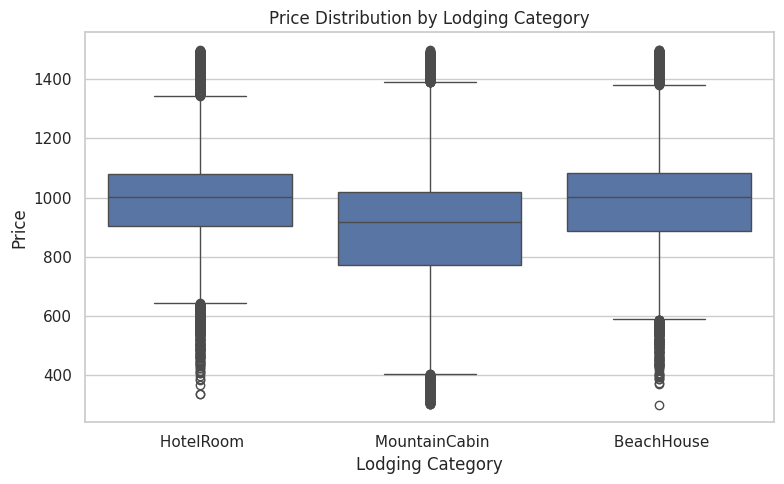

In [8]:
# Visualization 2: Price Distribution by Category (Boxplot)
plt.figure()
sns.boxplot(data=df, x="category", y="price")
plt.title("Price Distribution by Lodging Category")
plt.xlabel("Lodging Category")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### Visualization 3: Average Monthly Price Over Time by Lodging Type (Line Plot)

This line plot shows how the average monthly nightly price changes over time for the two lodging types: Travel (HotelRoom and MountainCabin) and Vacation (BeachHouse).

The data is first grouped by month, and the mean price is calculated separately for Travel and Vacation listings for each month. These monthly averages are then plotted over time to observe long-term trends rather than daily fluctuations.

This visualization helps identify seasonal pricing patterns, compare price stability between Travel and Vacation rentals, and determine whether one lodging type consistently remains more expensive throughout the year.

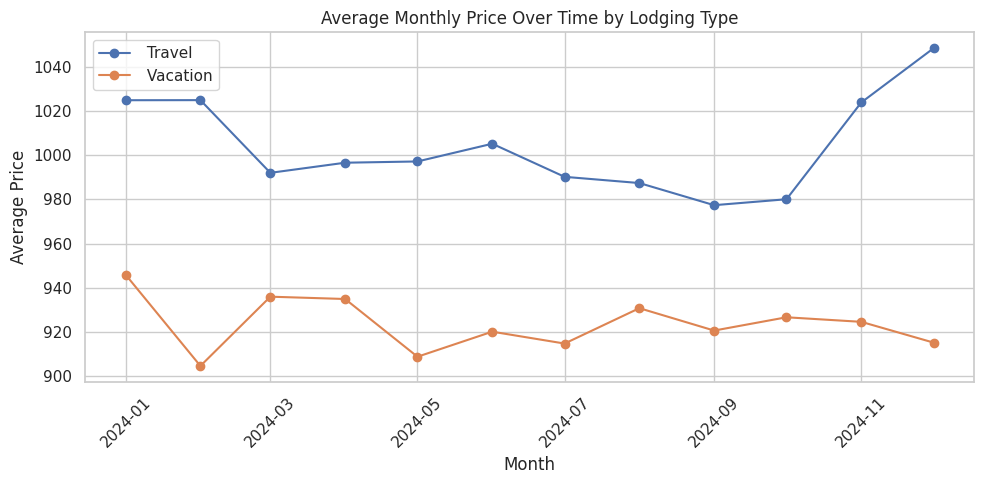

In [9]:
# Visualization 3: Average Price Over Time by Lodging Type (Monthly Line Plot)

import matplotlib.pyplot as plt
import pandas as pd

# Ensure date is datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Drop rows where date is missing
df_time = df.dropna(subset=["date"]).copy()

# Create a Month column (Year-Month)
df_time["month"] = df_time["date"].dt.to_period("M").dt.to_timestamp()

# Compute monthly average price by lodging type (Travel vs Vacation)
monthly_avg = (
    df_time
    .groupby(["month", "type"], as_index=False)["price"]
    .mean()
)

# Plot
plt.figure(figsize=(10, 5))
for t in monthly_avg["type"].unique():
    subset = monthly_avg[monthly_avg["type"] == t]
    plt.plot(subset["month"], subset["price"], marker="o", label=t)

plt.title("Average Monthly Price Over Time by Lodging Type")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Visualization 4: Price vs Rating by Lodging Category (Scatter Plot)

This scatter plot shows the relationship between customer ratings and nightly prices for different lodging categories: HotelRoom, MountainCabin, and BeachHouse. Each point represents one listing, with the x-axis showing the customer rating and the y-axis showing the price in USD.

From the plot, we observe that higher ratings occur across a wide range of prices, indicating that higher price does not always guarantee a higher rating. Mountain Cabins and Beach Houses show a wider spread of prices at higher rating levels compared to Hotel Rooms. Overall, this visualization suggests that customer satisfaction is influenced by factors beyond just pricing.
The vertical clustering at each rating level occurs because ratings are discrete values from 1 to 5.


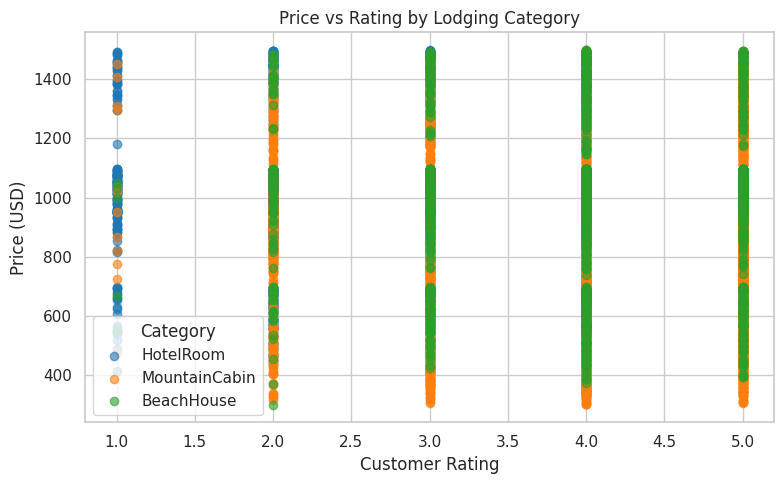

In [10]:
# Visualization 4: Price vs Rating by Lodging Category (Corrected Scatter Plot)

plt.figure(figsize=(8, 5))

# Clean category values first (IMPORTANT FIX)
df["category"] = df["category"].str.strip()

color_map = {
    "HotelRoom": "#1f77b4",      # Blue
    "MountainCabin": "#ff7f0e",  # Orange
    "BeachHouse": "#2ca02c"      # Green
}

for cat, color in color_map.items():
    subset = df[df["category"].str.contains(cat, case=False, na=False)]

    plt.scatter(
        subset["rating"],
        subset["price"],
        alpha=0.6,
        color=color,
        label=cat
    )

plt.title("Price vs Rating by Lodging Category")
plt.xlabel("Customer Rating")
plt.ylabel("Price (USD)")
plt.legend(title="Category")
plt.grid(True)
plt.tight_layout()
plt.show()




### Visualization 5: Distribution of Lodging Ratings (Histogram)

This histogram shows how lodging ratings are distributed in the dataset. Ratings range from 1.0
to 5.0, and the histogram groups these values into bins to display how frequently each rating appears.

This visualization helps us understand whether most lodgings tend to have high ratings, low ratings,
or if the ratings are evenly spread. It also gives a quick sense of customer satisfaction patterns
across all lodging categories in the dataset.


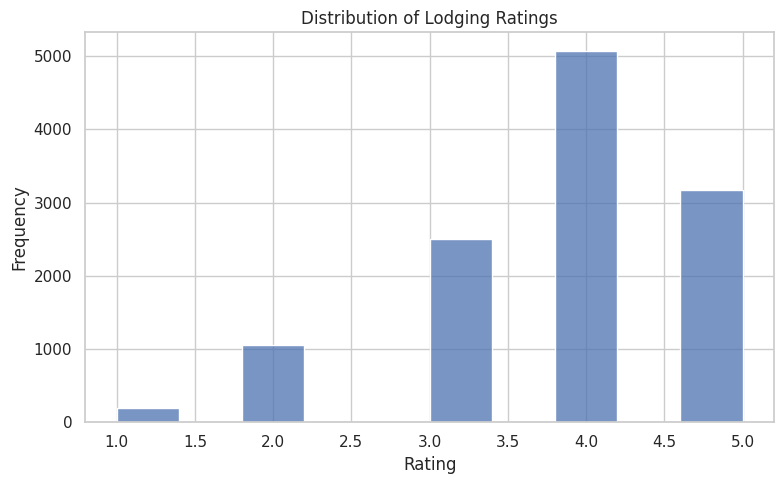

In [11]:
plt.figure()
sns.histplot(df["rating"], bins=10, kde=False)
plt.title("Distribution of Lodging Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


### Visualization 6: Heat Map of Rating vs Category (Categorical Heatmap)

This heatmap shows how customer ratings are distributed across different lodging categories using count values. The rows represent rating levels and the columns represent lodging categories. The color intensity shows how many listings fall into each rating–category group.

This visualization helps us see which categories receive more high ratings and which ones have more mid or low ratings. It clearly shows where customer satisfaction is strongest across the different lodging types.


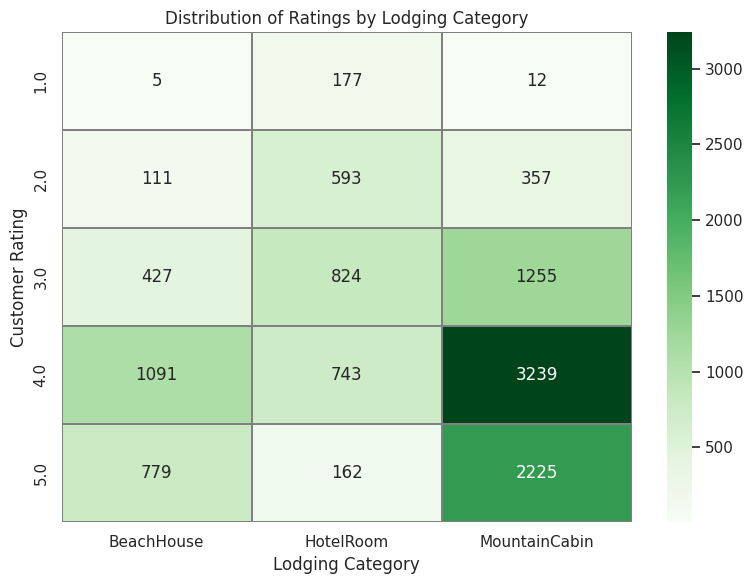

In [12]:
# Visualization 6: Categorical Heatmap (Rating vs Category - Count of Listings)

import seaborn as sns
import matplotlib.pyplot as plt

# Create categorical pivot table (Counts)
heatmap_data = pd.pivot_table(
    df,
    index="rating",
    columns="category",
    values="unique_id",
    aggfunc="count"
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Greens",
    linewidths=0.1,
    linecolor="gray"
)

plt.title("Distribution of Ratings by Lodging Category")
plt.xlabel("Lodging Category")
plt.ylabel("Customer Rating")
plt.tight_layout()
plt.show()


### Visualization 7: Distribution of Listings by Category (Pie Chart)

This pie chart shows the **proportion of listings** in each lodging category:
HotelRoom, MountainCabin, and BeachHouse.

By converting the category counts into percentages, the chart highlights which type of
lodging is most common in the dataset. This helps summarize the overall composition of
the portfolio and shows whether the travel agency focuses more on hotel rooms, cabins,
or beach houses.


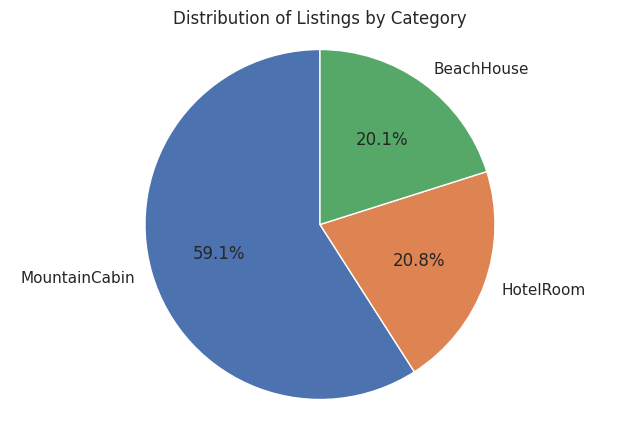

In [13]:
# Visualization 7: Distribution of Listings by Category (Pie Chart)

category_counts = df["category"].value_counts()

plt.figure()
plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribution of Listings by Category")
plt.axis("equal")  # Make sure pie is a circle
plt.show()


### Conclusion

Overall, the dataset shows a large and diverse lodging inventory with consistent patterns in pricing, ratings, and demand. Most listings in the dataset fall into the MountainCabin category, which also dominates the 4-star and 5-star rating range. Ratings in general are very positive, with most properties scoring above 3 stars and relatively few low-rated listings. Prices vary widely across the year, but the average revenue stays within a stable range, which suggests that demand remains steady even when nightly prices change.

When comparing lodging types, Travel listings (HotelRoom and MountainCabin) show more price fluctuations over time than Vacation listings (BeachHouse). However, both types maintain similar revenue levels, meaning higher prices do not automatically lead to higher revenue. The relationship between price and revenue appears fairly spread out, indicating that factors other than price may be influencing revenue.

Overall, the dataset reflects a well-performing lodging portfolio with strong ratings, balanced revenue distribution, and a noticeable concentration in MountainCabin properties.


### Recommendation

Based on the trends in the dataset, the company could benefit from increasing its focus on high-rated and high-demand categories, especially **MountainCabins**, since they make up the largest part of the portfolio and consistently show strong ratings and revenue. At the same time, **BeachHouse** listings also perform well and could be expanded to create a more balanced offering across lodging types.

Since revenue does not increase automatically with higher prices, the company should consider adjusting pricing strategies to focus on occupancy and customer experience instead of simply raising nightly rates. Investing in quality improvements for lower-rated properties may also help move them into the higher-rating groups that dominate revenue. Overall, the company should continue maintaining quality while diversifying its lodging types to strengthen both customer satisfaction and long-term revenue.
Future analysis can be strengthened by incorporating location data, property features, seasonal indicators, customer review text, and maintenance records.
